# PCA(主成分分析)降維實驗:一步步手刻

**這份筆記在做什麼?**

PCA(Principal Component Analysis)是最常用的**無監督**降維方法:
它不看類別標籤,只問一件事 —— **資料在哪些方向上「變異最大」?**
把資料投影到變異最大的前幾個方向(主成分),就能用更少的維度保留最多的資訊。

本實驗用鳶尾花資料(4 維 → 2 維),**全程手刻**每一步。

**學習地圖(也是 PCA 的計算流程):**

| 步驟 | 主題 | 做什麼 |
|:---:|---|---|
| 1 | 資料準備與觀察 | 讀取 iris、看各特徵的分布 |
| 2 | 標準化 | 把各特徵拉到同一尺度 |
| 3 | 協方差矩陣 | 描述特徵之間怎麼共同變動 |
| 4 | 特徵值分解 | 找出主成分,決定留幾維 |
| 5 | 投影與視覺化 | 降維前後對比 |

> 💡 請**由上往下依序執行**每個 cell(Shift + Enter)。

## 1. 資料讀取與觀察

### 1.1 讀取資料

注意 `header=None`:`iris.data` 的第一列就是資料,不是欄名 ——
少了這個參數,**第一筆樣本會被當成欄名吃掉**,整份實驗就只剩 149 筆了。

In [1]:
import numpy as np
import pandas as pd

# 讀取資料集(header=None:原始檔沒有欄名列,第一列就是資料)
df = pd.read_csv('iris.data', header=None)
# 原始數據沒有給定列名的時候需要我們自己加上
df.columns = ['sepal_len', 'sepal_wid', 'petal_len', 'petal_wid', 'class']
df.head()

,sepal_len,sepal_wid,petal_len,petal_wid,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
# 把數據分成特徵和標籤
X = df.iloc[:, 0:4].values   # 150×4 的特徵矩陣
y = df.iloc[:, 4].values     # 150 個品種標籤

### 1.2 觀察:每個特徵分得開三個品種嗎?

對 4 個特徵各畫一張直方圖,三個品種疊在一起比較:

In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

# 展示特徵用的名稱
feature_dict = {0: 'sepal length [cm]',
                1: 'sepal width [cm]',
                2: 'petal length [cm]',
                3: 'petal width [cm]'}

# 指定繪圖區域大小
plt.figure(figsize=(8, 6))
for cnt in range(4):
    # 這裏用子圖來呈現 4 個特徵
    plt.subplot(2, 2, cnt+1)
    for lab in ('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'):
        plt.hist(X[y == lab, cnt],
                     label=lab,
                     bins=10,
                     alpha=0.3,)
    plt.xlabel(feature_dict[cnt])
    plt.legend(loc='upper right', fancybox=True, fontsize=8)

plt.tight_layout()
plt.show()

**觀察結果:** 花瓣(petal)長、寬兩個特徵下,三個品種的分布明顯錯開;
花萼(sepal)兩個特徵則大量重疊 —— 4 個維度的「資訊量」並不平均,這正是降維的空間。

## 2. 標準化

一般情況都是先對資料進行**標準化**處理(每個特徵減均值、除以標準差)——
否則尺度大的特徵天然「變異大」,會霸佔主成分:

In [4]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)   # 每個特徵 → 均值 0、標準差 1

## 3. 計算協方差矩陣

協方差矩陣是一個 4×4 矩陣,描述**每一對特徵怎麼共同變動**:

$$\Sigma = \frac{1}{n-1}(X - \bar{x})^T(X - \bar{x})$$

- 對角線:各特徵自己的變異數(標準化後都接近 1)
- 非對角:兩特徵的相關程度(正 = 同漲同跌,負 = 一漲一跌)

先照公式手算:

In [5]:
mean_vec = np.mean(X_std, axis=0)
cov_mat = (X_std - mean_vec).T.dot((X_std - mean_vec)) / (X_std.shape[0] - 1)
print('協方差矩陣 \n%s' % cov_mat)

協方差矩陣 
[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


再用 NumPy 現成的 `np.cov` 驗證(結果應該一模一樣):

In [6]:
print('NumPy 計算協方差矩陣: \n%s' % np.cov(X_std.T))

NumPy 計算協方差矩陣: 
[[ 1.00671141 -0.11010327  0.87760486  0.82344326]
 [-0.11010327  1.00671141 -0.42333835 -0.358937  ]
 [ 0.87760486 -0.42333835  1.00671141  0.96921855]
 [ 0.82344326 -0.358937    0.96921855  1.00671141]]


兩者一致 ✅。可以看到花瓣長、寬和花萼長之間高度正相關(0.87、0.82、0.96)——
特徵之間高度相關,代表**存在冗餘**,降維有得賺。

## 4. 特徵值分解:找出主成分

對協方差矩陣做特徵值分解:

- **特徵向量**:主成分的方向(資料變異最大的那些互相垂直的方向)
- **特徵值**:資料在該方向上的變異量(= 這個主成分承載了多少資訊)

In [7]:
cov_mat = np.cov(X_std.T)

eig_vals, eig_vecs = np.linalg.eig(cov_mat)   # 特徵值分解

print('特徵向量 \n%s' % eig_vecs)
print('\n特徵值 \n%s' % eig_vals)

特徵向量 
[[ 0.52237162 -0.37231836 -0.72101681  0.26199559]
 [-0.26335492 -0.92555649  0.24203288 -0.12413481]
 [ 0.58125401 -0.02109478  0.14089226 -0.80115427]
 [ 0.56561105 -0.06541577  0.6338014   0.52354627]]

特徵值 
[2.93035378 0.92740362 0.14834223 0.02074601]


把特徵值和對應的特徵向量配成對,按特徵值**由大到小**排序:

In [8]:
# 把特徵值和特徵向量對應起來
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:, i]) for i in range(len(eig_vals))]
print(eig_pairs)
print('----------')
# 把它們按照特徵值大小進行排序
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# 打印排序結果
print('特徵值由大到小排序結果:')
for i in eig_pairs:
    print(i[0])

[(np.float64(2.9303537755893183), array([ 0.52237162, -0.26335492,  0.58125401,  0.56561105])), (np.float64(0.9274036215173416), array([-0.37231836, -0.92555649, -0.02109478, -0.06541577])), (np.float64(0.14834222648164005), array([-0.72101681,  0.24203288,  0.14089226,  0.6338014 ])), (np.float64(0.020746013995595898), array([ 0.26199559, -0.12413481, -0.80115427,  0.52354627]))]
----------
特徵值由大到小排序結果:
2.9303537755893183
0.9274036215173416
0.14834222648164005
0.020746013995595898


### 4.1 解釋變異比例:該留幾個主成分?

把每個特徵值除以總和,就是各主成分「解釋」了多少比例的變異;再算**累加**:

In [9]:
# 計算累加結果
tot = sum(eig_vals)
var_exp = [(i / tot) * 100 for i in sorted(eig_vals, reverse=True)]   # 各主成分的解釋比例(%)
print(var_exp)
cum_var_exp = np.cumsum(var_exp)   # 累加:前 k 個主成分合計解釋多少
cum_var_exp

[np.float64(72.77045209380135), np.float64(23.030523267680632), np.float64(3.6838319576273917), np.float64(0.5151926808906311)]


array([ 72.77045209,  95.80097536,  99.48480732, 100.        ])

(`np.cumsum` 就是「一路加上去」,用小例子確認它的行為:)

In [10]:
a = np.array([1, 2, 3, 4])
print(a)
print('-----------')
print(np.cumsum(a))   # [1, 1+2, 1+2+3, 1+2+3+4]

[1 2 3 4]
-----------
[ 1  3  6 10]


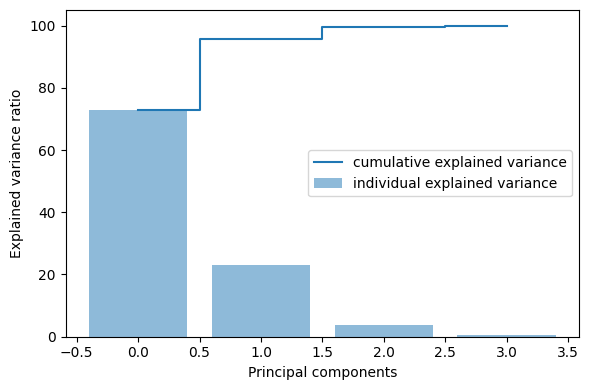

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(range(4), var_exp, alpha=0.5, align='center',
            label='individual explained variance')      # 長條:各主成分單獨的貢獻
plt.step(range(4), cum_var_exp, where='mid',
             label='cumulative explained variance')     # 階梯線:累加貢獻
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

**觀察結果:** 第 1 個主成分獨佔約 73%,前兩個合計約 **96%** ——
4 維資料的絕大多數資訊,用 2 維就裝得下。所以取前 2 個主成分。

### 4.2 組成投影矩陣 W

In [12]:
matrix_w = np.hstack((eig_pairs[0][1].reshape(4, 1),
                      eig_pairs[1][1].reshape(4, 1)))   # 取前 2 大特徵值對應的特徵向量

print('Matrix W:\n', matrix_w)

Matrix W:
 [[ 0.52237162 -0.37231836]
 [-0.26335492 -0.92555649]
 [ 0.58125401 -0.02109478]
 [ 0.56561105 -0.06541577]]


## 5. 執行降維並視覺化

降維就是一次矩陣乘法:150×4 的標準化資料,乘上 4×2 的投影矩陣 → 150×2:

In [13]:
Y = X_std.dot(matrix_w)
Y

array([[-2.26454173e+00, -5.05703903e-01],
       [-2.08642550e+00,  6.55404729e-01],
       [-2.36795045e+00,  3.18477311e-01],
       [-2.30419716e+00,  5.75367713e-01],
       [-2.38877749e+00, -6.74767397e-01],
       [-2.07053681e+00, -1.51854856e+00],
       [-2.44571134e+00, -7.45626750e-02],
       [-2.23384186e+00, -2.47613932e-01],
       [-2.34195768e+00,  1.09514636e+00],
       [-2.18867576e+00,  4.48629048e-01],
       [-2.16348656e+00, -1.07059558e+00],
       [-2.32737775e+00, -1.58587455e-01],
       [-2.22408272e+00,  7.09118158e-01],
       [-2.63971626e+00,  9.38281982e-01],
       [-2.19229151e+00, -1.88997851e+00],
       [-2.25146521e+00, -2.72237108e+00],
       [-2.20275048e+00, -1.51375028e+00],
       [-2.19017916e+00, -5.14304308e-01],
       [-1.89407429e+00, -1.43111071e+00],
       [-2.33994907e+00, -1.15803343e+00],
       [-1.91455639e+00, -4.30465163e-01],
       [-2.20464540e+00, -9.52457317e-01],
       [-2.77416979e+00, -4.89517027e-01],
       [-1.

**降維前**(不動腦地取前兩個原始特徵 sepal_len、sepal_wid):

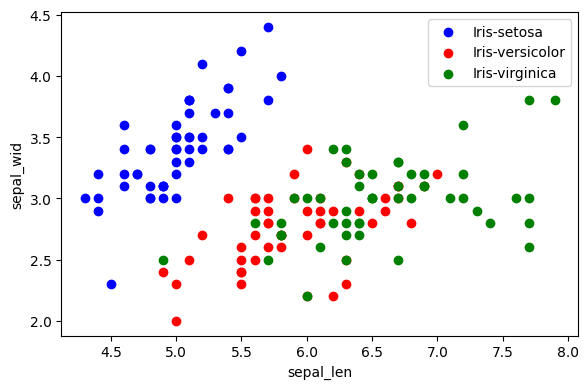

In [14]:
plt.figure(figsize=(6, 4))
for lab, col in zip(('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'),
                        ('blue', 'red', 'green')):
     plt.scatter(X[y == lab, 0],
                X[y == lab, 1],
                label=lab,
                c=col)
plt.xlabel('sepal_len')
plt.ylabel('sepal_wid')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

**降維後**(PCA 找出的前兩個主成分):

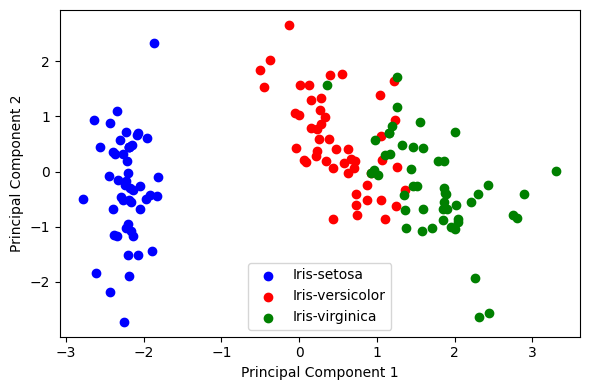

In [15]:
plt.figure(figsize=(6, 4))
for lab, col in zip(('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'),
                        ('blue', 'red', 'green')):
     plt.scatter(Y[y == lab, 0],
                Y[y == lab, 1],
                label=lab,
                c=col)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='lower center')
plt.tight_layout()
plt.show()

**觀察結果:** 隨便取兩個原始特徵(上圖),紅、綠兩類大面積重疊;
PCA 的前兩個主成分(下圖)把三類沿第一主成分方向排開,**同樣是 2 維,保留的資訊多得多**。

值得注意:PCA 全程**沒看過任何類別標籤**,類別分開只是「變異最大方向恰好和類別方向一致」的副產品。

## 總結:這份實驗的重點整理

| # | 重點 |
|:---:|---|
| 1 | PCA 是**無監督**降維:找「資料變異最大」的互相垂直方向(主成分) |
| 2 | 流程:**標準化 → 協方差矩陣 → 特徵值分解 → 按特徵值排序 → 取前 k 個方向 → $X \cdot W$ 投影** |
| 3 | **特徵向量 = 主成分方向,特徵值 = 該方向的變異量(資訊量)** |
| 4 | 用**累計解釋變異比例**決定留幾維(iris:前 2 維 ≈ 96%) |
| 5 | 標準化不可省:否則尺度大的特徵會霸佔主成分 |
| 6 | 對照:**PCA 無監督、看變異;LDA 有監督、看類別分離**(見 LDA 篇) |

**多做實驗,得出結果!!!**